# Structured DAG Generation — Examples

This notebook demonstrates `generate_structured_dag()`, which produces DAGs with
four semantic node roles:

| Role | Prefix | Color | Description |
|------|--------|-------|-------------|
| Start (ligand) | `L` | green | Upstream input nodes |
| End (readout) | `R` | tomato | Downstream output nodes |
| Mediator | `M` | steelblue | Intermediate signaling nodes |
| Confounder | `C` | orchid | Latent common causes |

Connectivity is structured rather than random:
- Each start node connects to 1–few end nodes (truncated geometric, not all-to-all)
- Mediator chain length per path is sampled from `[0, max_mediators]`
- Cross-talk via shared mediators is controlled by `shared_mediator_prob`
- Confounders point into 2 randomly selected observable nodes

In [1]:
import sys
sys.path.insert(0, '../../src')

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

from causomic.simulation.random_network import generate_structured_dag
from causomic.simulation.random_network import generate_indra_data


SPURIOUS_NODE_COLOR = '#FF9800'   # orange  — X nodes
TRUE_EDGE_COLOR     = '#2E7D32'   # dark green — real edge present in INDRA
FALSE_EDGE_COLOR    = '#D32F2F'   # dark red   — spurious edge
MISSING_EDGE_COLOR  = '#9E9E9E'   # grey       — real edge absent from INDRA


/Users/kohler.d/miniconda3/envs/Causomic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Helpers ──────────────────────────────────────────────────────────────────

ROLE_COLORS = {
    'start':      '#4CAF50',   # green
    'end':        '#F44336',   # tomato red
    'mediators':  '#2196F3',   # steel blue
    'confounders':'#9C27B0',   # purple
}

LEGEND_LABELS = {
    'start':      'Start (ligand)',
    'end':        'End (readout)',
    'mediators':  'Mediator',
    'confounders':'Confounder',
}


def dag_layout(dag, node_roles):
    """Hierarchical layout: columns by topological generation, with
    confounders placed above the layer they connect to most.
    End nodes are forced to the rightmost layer so mediators always
    appear between start and end columns."""
    # Assign layers to non-confounder nodes via topological generations
    conf_set = set(node_roles['confounders'])
    end_set  = set(node_roles['end'])
    subgraph = dag.subgraph([n for n in dag.nodes if n not in conf_set])

    generations = list(nx.topological_generations(subgraph))
    layer_map = {}
    for layer_idx, gen in enumerate(generations):
        for node in gen:
            layer_map[node] = layer_idx

    # Force all end nodes to the rightmost layer so mediators are always
    # visually sandwiched between start and end columns.
    max_layer = max(layer_map.values()) if layer_map else 0
    for n in end_set:
        if n in layer_map:
            layer_map[n] = max_layer

    # Assign confounders a layer based on their minimum successor layer
    for cnode in conf_set:
        successors = list(dag.successors(cnode))
        if successors:
            layer_map[cnode] = min(layer_map.get(s, 0) for s in successors) - 0.5
        else:
            layer_map[cnode] = -0.5

    # Build multipartite-style positions
    from collections import defaultdict
    layer_nodes = defaultdict(list)
    for node, lyr in layer_map.items():
        layer_nodes[lyr].append(node)

    pos = {}
    for lyr, nodes in sorted(layer_nodes.items()):
        nodes_sorted = sorted(nodes)
        for i, node in enumerate(nodes_sorted):
            pos[node] = (lyr * 2.0, i - len(nodes_sorted) / 2.0)
    return pos


def node_colors(dag, node_roles):
    role_lookup = {}
    for role, nodes in node_roles.items():
        for n in nodes:
            role_lookup[n] = role
    return [ROLE_COLORS[role_lookup[n]] for n in dag.nodes()]


def plot_dag(dag, node_roles, title='', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    pos = dag_layout(dag, node_roles)
    colors = node_colors(dag, node_roles)

    nx.draw_networkx(
        dag, pos=pos, ax=ax,
        node_color=colors,
        node_size=700,
        font_size=9,
        font_color='white',
        font_weight='bold',
        edge_color='#555555',
        arrows=True,
        arrowsize=14,
        width=1.5,
        connectionstyle='arc3,rad=0.1',
    )

    patches = [
        mpatches.Patch(color=color, label=LEGEND_LABELS[role])
        for role, color in ROLE_COLORS.items()
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=8, framealpha=0.8)

    n_nodes = dag.number_of_nodes()
    n_edges = dag.number_of_edges()
    ax.set_title(
        f"{title}\n{n_nodes} nodes · {n_edges} edges",
        fontsize=11, pad=10
    )
    ax.axis('off')

    return ax

## Example 1 — Minimal: 2 start, 2 end, no cross-talk

Node roles:
  start       : ['L0', 'L1']
  end         : ['R0', 'R1']
  mediators   : ['M0', 'M1', 'M2', 'M3']
  confounders : []


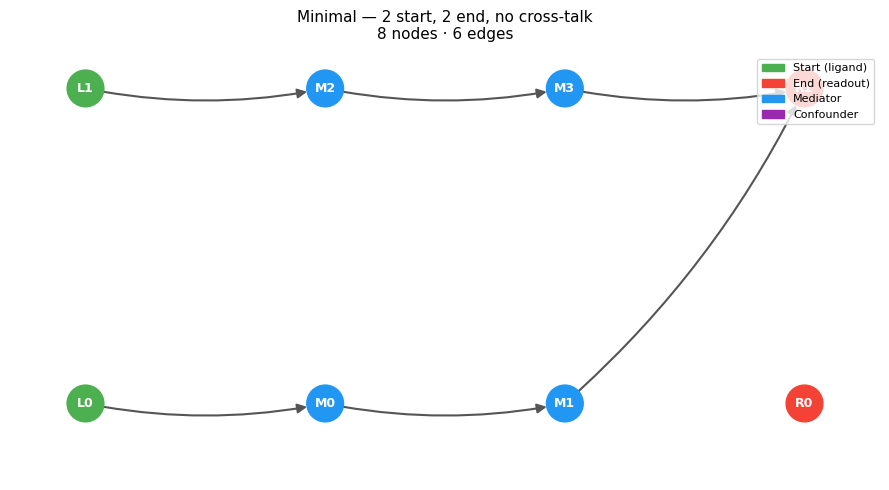

In [3]:
dag1, roles1 = generate_structured_dag(
    n_start=2,
    n_end=2,
    max_mediators=2,
    confounder_prob=0.05,
    shared_mediator_prob=0.0,   # no cross-talk — each path is independent
    seed=1,
)

print("Node roles:")
for role, nodes in roles1.items():
    print(f"  {role:12s}: {nodes}")

plot_dag(dag1, roles1, title='Minimal — 2 start, 2 end, no cross-talk')
plt.tight_layout()
plt.show()

## Example 2 — Cross-talk via shared mediators

Node roles:
  start       : ['L0', 'L1', 'L2']
  end         : ['R0', 'R1', 'R2']
  mediators   : ['M0', 'M1', 'M2', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
  confounders : ['C0', 'C1']


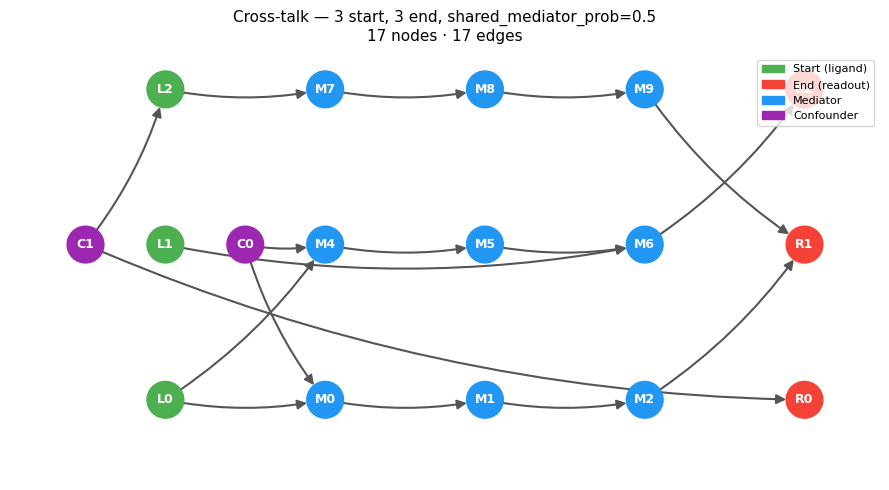

In [4]:
dag2, roles2 = generate_structured_dag(
    n_start=3,
    n_end=3,
    max_mediators=3,
    confounder_prob=0.15,
    shared_mediator_prob=0.5,   # 50% chance of reusing mediators → cross-talk
    seed=7,
)

print("Node roles:")
for role, nodes in roles2.items():
    print(f"  {role:12s}: {nodes}")

plot_dag(dag2, roles2, title='Cross-talk — 3 start, 3 end, shared_mediator_prob=0.5')
plt.tight_layout()
plt.show()

## Example 3 — Larger signaling-like network with many confounders

Node roles:
  start       : ['L0', 'L1', 'L2', 'L3']
  end         : ['R0', 'R1', 'R2', 'R3', 'R4']
  mediators   : ['M0', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10']
  confounders : ['C0', 'C1', 'C2', 'C3', 'C4']


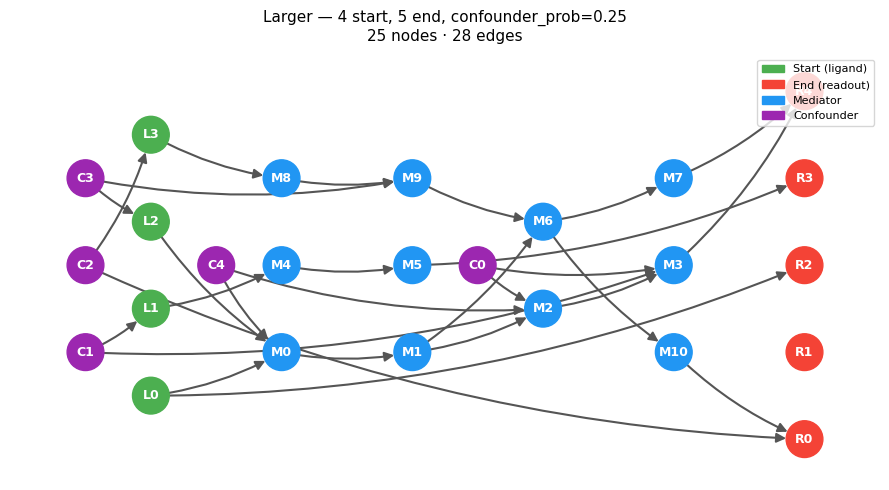

In [5]:
dag3, roles3 = generate_structured_dag(
    n_start=4,
    n_end=5,
    max_mediators=4,
    confounder_prob=0.25,       # roughly 1 confounder per 4 observable nodes
    shared_mediator_prob=0.4,
    seed=42,
)

print("Node roles:")
for role, nodes in roles3.items():
    print(f"  {role:12s}: {nodes}")

plot_dag(dag3, roles3, title='Larger — 4 start, 5 end, confounder_prob=0.25')
plt.tight_layout()
plt.show()

## Example 4 — Side-by-side: varying max_mediators

Holding all other parameters fixed, increasing `max_mediators` grows longer
signaling chains between ligands and readouts.

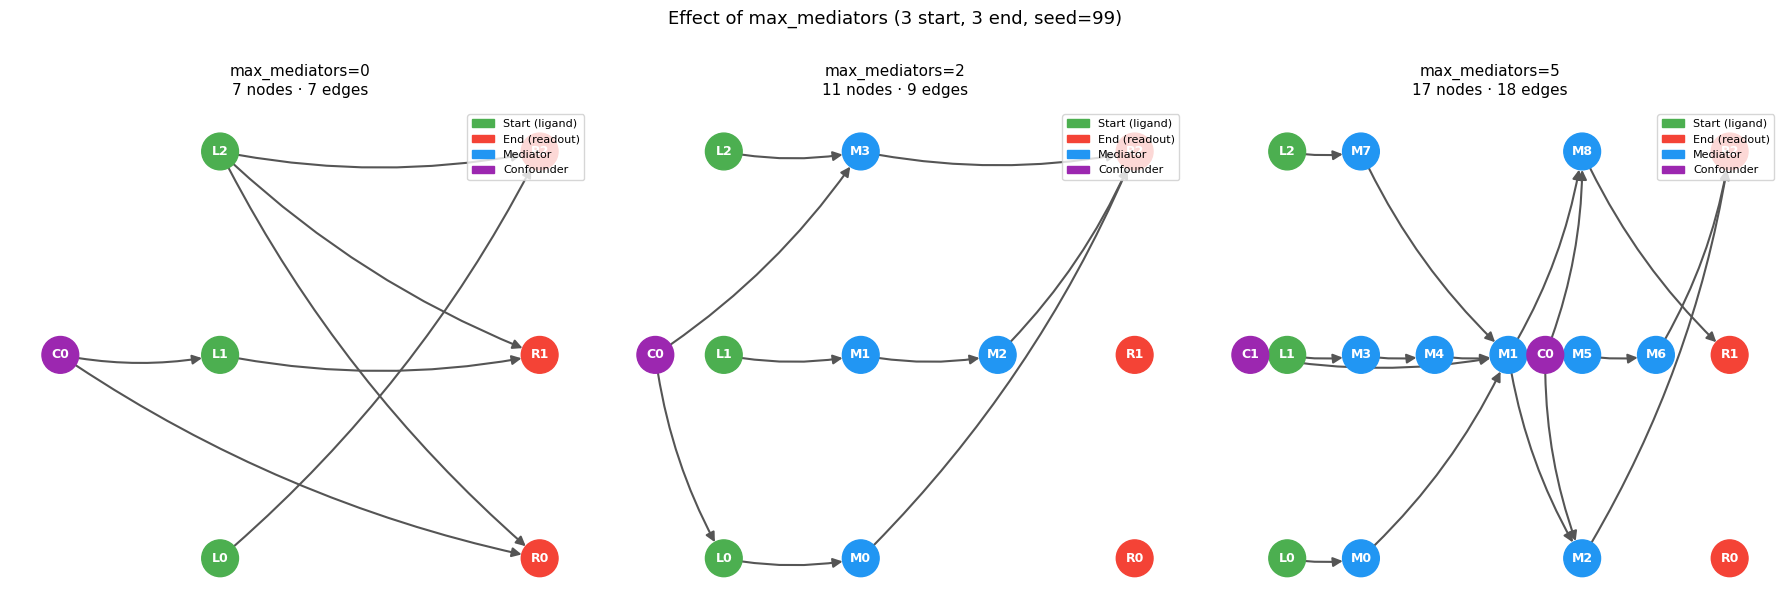

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, max_med in zip(axes, [0, 2, 5]):
    dag, roles = generate_structured_dag(
        n_start=3,
        n_end=3,
        max_mediators=max_med,
        confounder_prob=0.1,
        shared_mediator_prob=0.3,
        seed=99,
    )
    plot_dag(dag, roles, title=f'max_mediators={max_med}', ax=ax)

plt.suptitle('Effect of max_mediators (3 start, 3 end, seed=99)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Example 5 — Side-by-side: varying confounder_prob

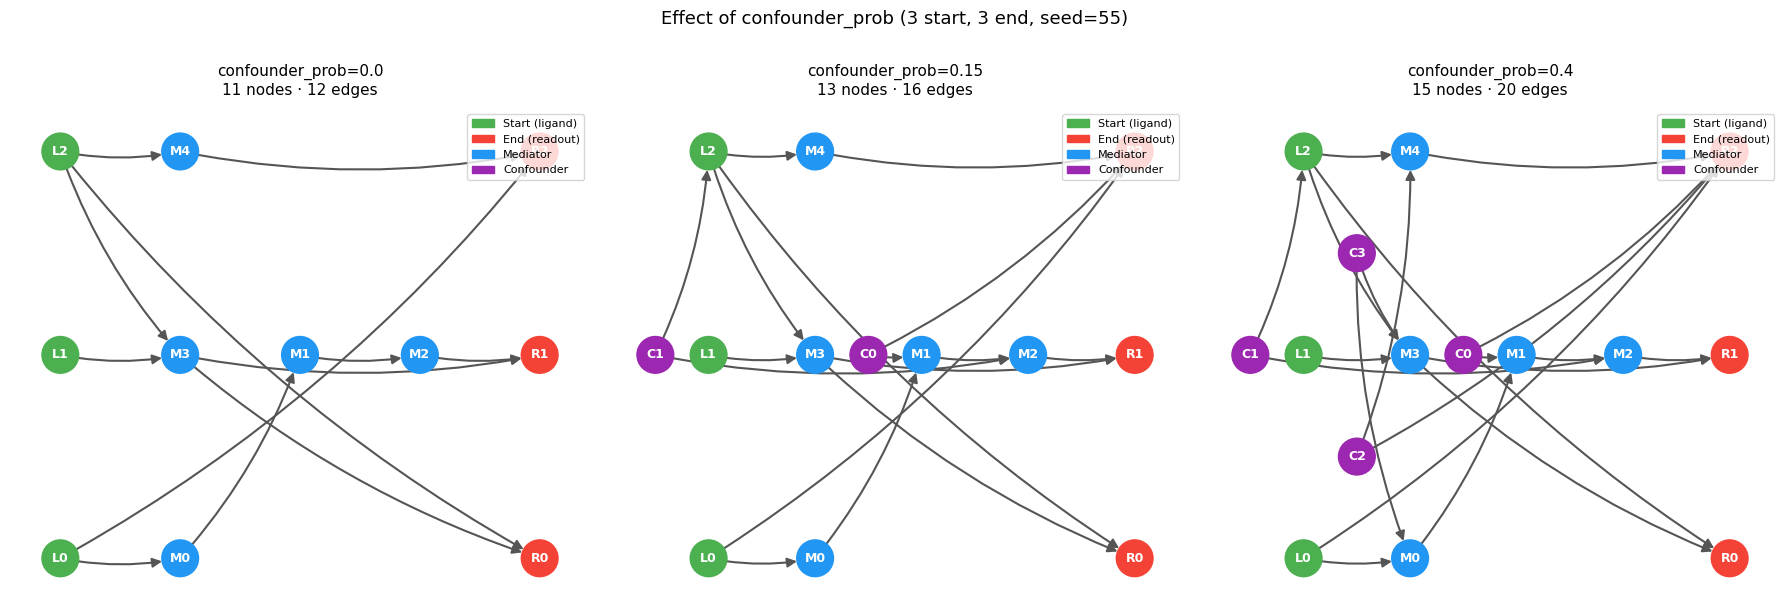

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, conf_prob in zip(axes, [0.0, 0.15, 0.4]):
    dag, roles = generate_structured_dag(
        n_start=3,
        n_end=3,
        max_mediators=3,
        confounder_prob=conf_prob,
        shared_mediator_prob=0.3,
        seed=55,
    )
    plot_dag(dag, roles, title=f'confounder_prob={conf_prob}', ax=ax)

plt.suptitle('Effect of confounder_prob (3 start, 3 end, seed=55)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Verify DAG validity across many random seeds

In [8]:
import networkx as nx

n_trials = 200
failures = []

for seed in range(n_trials):
    dag, roles = generate_structured_dag(
        n_start=np.random.randint(1, 6),
        n_end=np.random.randint(1, 6),
        max_mediators=np.random.randint(0, 6),
        confounder_prob=np.random.uniform(0, 0.3),
        shared_mediator_prob=np.random.uniform(0, 1),
        seed=seed,
    )
    if not nx.is_directed_acyclic_graph(dag):
        failures.append(seed)

if failures:
    print(f"FAILED on seeds: {failures}")
else:
    print(f"All {n_trials} trials produced valid DAGs.")

All 200 trials produced valid DAGs.


---

## INDRA Evidence — Ground Truth vs INDRA Graph

`generate_indra_data()` takes the ground truth DAG and produces a noisy INDRA-style
prior graph by:
- **Keeping** most true edges (with integer evidence counts)
- **Dropping** some true edges with probability `p_missing_real` (edges INDRA has no record of)
- **Adding** spurious nodes (`X…`) and spurious edges between existing nodes

The plots below use the following edge/node conventions:

| Element | Style | Meaning |
|---------|-------|---------|
| Solid colored edges | — | Edge present in INDRA with `ground_truth=True` |
| Dashed red edges | - - | Spurious edge (`ground_truth=False`) |
| Dashed grey edges | - - | Missing true edge (absent from INDRA) |
| `X` nodes | light orange | Spurious nodes added by INDRA noise |

In [9]:

def indra_layout(indra_dag, gt_dag, node_roles):
    """Hierarchical positions derived from gt_dag (always acyclic).
    Spurious X nodes are placed within the hierarchy at the midpoint
    between their real-node predecessors and successors, so on-path
    insertions appear between the columns they connect rather than in
    a separate side column."""
    from collections import defaultdict
    real_pos = dag_layout(gt_dag, node_roles)
    real_nodes = set(gt_dag.nodes())
    x_nodes = [n for n in indra_dag.nodes if n not in real_nodes]
    if not x_nodes:
        return real_pos

    max_real_x = max(p[0] for p in real_pos.values())

    # Place each x_node at the midpoint between its real-node neighbours
    x_col_map = {}
    for xn in x_nodes:
        real_preds = [p for p in indra_dag.predecessors(xn) if p in real_nodes]
        real_succs = [s for s in indra_dag.successors(xn) if s in real_nodes]
        if real_preds and real_succs:
            pred_x = max(real_pos[p][0] for p in real_preds)
            succ_x = min(real_pos[s][0] for s in real_succs)
            x_col_map[xn] = (pred_x + succ_x) / 2.0
        elif real_preds:
            x_col_map[xn] = max(real_pos[p][0] for p in real_preds) + 1.0
        elif real_succs:
            x_col_map[xn] = min(real_pos[s][0] for s in real_succs) - 1.0
        else:
            x_col_map[xn] = max_real_x + 3.0  # isolated: side column

    # Group x_nodes by column and spread vertically
    col_groups = defaultdict(list)
    for xn, xc in x_col_map.items():
        col_groups[xc].append(xn)

    for xc, group in col_groups.items():
        for i, xn in enumerate(sorted(group)):
            real_pos[xn] = (xc, i - len(group) / 2.0)

    return real_pos


def indra_node_colors(indra_dag, real_nodes, node_roles):
    role_lookup = {}
    for role, nodes in node_roles.items():
        for n in nodes:
            role_lookup[n] = role
    colors = []
    for n in indra_dag.nodes():
        if n in real_nodes:
            colors.append(ROLE_COLORS[role_lookup[n]])
        else:
            colors.append(SPURIOUS_NODE_COLOR)
    return colors


def plot_indra_comparison(gt_dag, roles, indra_dag, missing_edges,
                          p_missing_real=0.0, figsize=(16, 6)):
    """Side-by-side: ground truth (with missing edges marked) vs INDRA graph."""
    fig, (ax_gt, ax_indra) = plt.subplots(1, 2, figsize=figsize)
    real_nodes = set(gt_dag.nodes())

    # ── Left: ground truth with missing edges shown as dashed grey ───────────
    gt_pos = dag_layout(gt_dag, roles)
    gt_colors = node_colors(gt_dag, roles)

    present_edges = [e for e in gt_dag.edges() if e not in missing_edges]
    absent_edges  = list(missing_edges)

    nx.draw_networkx_nodes(gt_dag, gt_pos, ax=ax_gt,
                           node_color=gt_colors, node_size=700)
    nx.draw_networkx_labels(gt_dag, gt_pos, ax=ax_gt,
                            font_size=9, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(gt_dag, gt_pos, edgelist=present_edges, ax=ax_gt,
                           edge_color=TRUE_EDGE_COLOR, width=2.0,
                           arrows=True, arrowsize=14,
                           connectionstyle='arc3,rad=0.1')
    if absent_edges:
        nx.draw_networkx_edges(gt_dag, gt_pos, edgelist=absent_edges, ax=ax_gt,
                               edge_color=MISSING_EDGE_COLOR, width=1.5,
                               style='dashed', arrows=True, arrowsize=12,
                               connectionstyle='arc3,rad=0.1')

    gt_patches = [
        mpatches.Patch(color=c, label=l) for c, l in zip(
            [ROLE_COLORS['start'], ROLE_COLORS['end'],
             ROLE_COLORS['mediators'], ROLE_COLORS['confounders']],
            ['Start', 'End', 'Mediator', 'Confounder']
        )
    ] + [
        mpatches.Patch(color=TRUE_EDGE_COLOR,   label=f'True edge ({len(present_edges)})'),
        mpatches.Patch(color=MISSING_EDGE_COLOR, label=f'Missing from INDRA ({len(absent_edges)})'),
    ]
    ax_gt.legend(handles=gt_patches, loc='upper right', fontsize=7.5, framealpha=0.85)
    ax_gt.set_title(
        f'Ground Truth DAG\n{gt_dag.number_of_nodes()} nodes · '
        f'{gt_dag.number_of_edges()} edges · {len(absent_edges)} missing',
        fontsize=11
    )
    ax_gt.axis('off')

    # ── Right: INDRA graph ────────────────────────────────────────────────────
    indra_pos    = indra_layout(indra_dag, gt_dag, roles)
    indra_colors = indra_node_colors(indra_dag, real_nodes, roles)

    true_edges  = [(u, v) for u, v, d in indra_dag.edges(data=True)
                   if d.get('ground_truth')]
    false_edges = [(u, v) for u, v, d in indra_dag.edges(data=True)
                   if not d.get('ground_truth')]

    nx.draw_networkx_nodes(indra_dag, indra_pos, ax=ax_indra,
                           node_color=indra_colors, node_size=700)
    nx.draw_networkx_labels(indra_dag, indra_pos, ax=ax_indra,
                            font_size=9, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(indra_dag, indra_pos, edgelist=true_edges, ax=ax_indra,
                           edge_color=TRUE_EDGE_COLOR, width=2.0,
                           arrows=True, arrowsize=14,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(indra_dag, indra_pos, edgelist=false_edges, ax=ax_indra,
                           edge_color=FALSE_EDGE_COLOR, width=1.2,
                           style='dashed', arrows=True, arrowsize=11,
                           connectionstyle='arc3,rad=0.1')

    indra_patches = [
        mpatches.Patch(color=c, label=l) for c, l in zip(
            [ROLE_COLORS['start'], ROLE_COLORS['end'],
             ROLE_COLORS['mediators'], ROLE_COLORS['confounders'],
             SPURIOUS_NODE_COLOR],
            ['Start', 'End', 'Mediator', 'Confounder', 'Spurious node']
        )
    ] + [
        mpatches.Patch(color=TRUE_EDGE_COLOR,  label=f'True edge ({len(true_edges)})'),
        mpatches.Patch(color=FALSE_EDGE_COLOR, label=f'Spurious edge ({len(false_edges)})'),
    ]
    ax_indra.legend(handles=indra_patches, loc='upper right', fontsize=7.5, framealpha=0.85)
    ax_indra.set_title(
        f'INDRA Graph (p_missing={p_missing_real})\n'
        f'{indra_dag.number_of_nodes()} nodes · {indra_dag.number_of_edges()} edges · '
        f'{len(true_edges)} true / {len(false_edges)} spurious',
        fontsize=11
    )
    ax_indra.axis('off')

    fig.tight_layout()
    return fig

## Example 6 — Ground truth vs INDRA (no missing edges)

`p_missing_real=0.0`: every true edge appears in INDRA, but spurious nodes and edges are added.

Ground truth edges: 17
True edges in INDRA: 17  |  Spurious: 28
Missing from INDRA:  0

Evidence count summary:
              count  mean  std  min  25%  50%  75%   max
ground_truth                                            
False          28.0   1.6  1.1  1.0  1.0  1.0  2.0   4.0
True           17.0   4.4  4.9  1.0  1.0  2.0  7.0  14.0


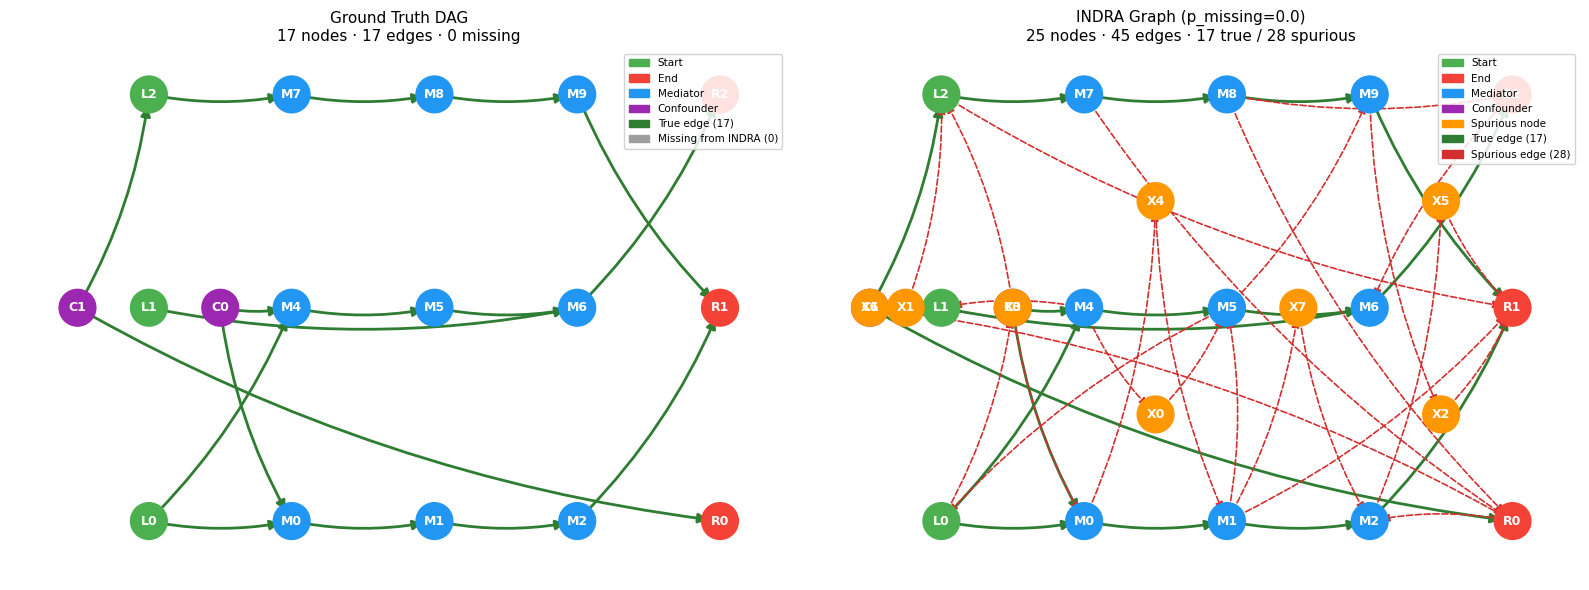

In [10]:
dag6, roles6 = generate_structured_dag(
    n_start=3, n_end=3, max_mediators=3,
    confounder_prob=0.15, shared_mediator_prob=0.4, seed=7,
)
indra6, df6, missing6 = generate_indra_data(
    dag6, num_incorrect_nodes=8, num_incorrect_edges=15, p_missing_real=0.0,
)
print(f"Ground truth edges: {dag6.number_of_edges()}")
print(f"True edges in INDRA: {df6.ground_truth.sum()}  |  Spurious: {(~df6.ground_truth).sum()}")
print(f"Missing from INDRA:  {len(missing6)}")
print()
print("Evidence count summary:")
print(df6.groupby('ground_truth')['evidence_count'].describe().round(1).to_string())

plot_indra_comparison(dag6, roles6, indra6, missing6, p_missing_real=0.0)
plt.show()

## Example 7 — Ground truth vs INDRA (with missing edges)

`p_missing_real=0.4`: 40% of true edges have no INDRA evidence — shown as dashed grey on
the ground truth side and simply absent from the INDRA graph.

Ground truth edges: 17
True edges in INDRA: 13  |  Spurious: 26
Missing from INDRA:  4


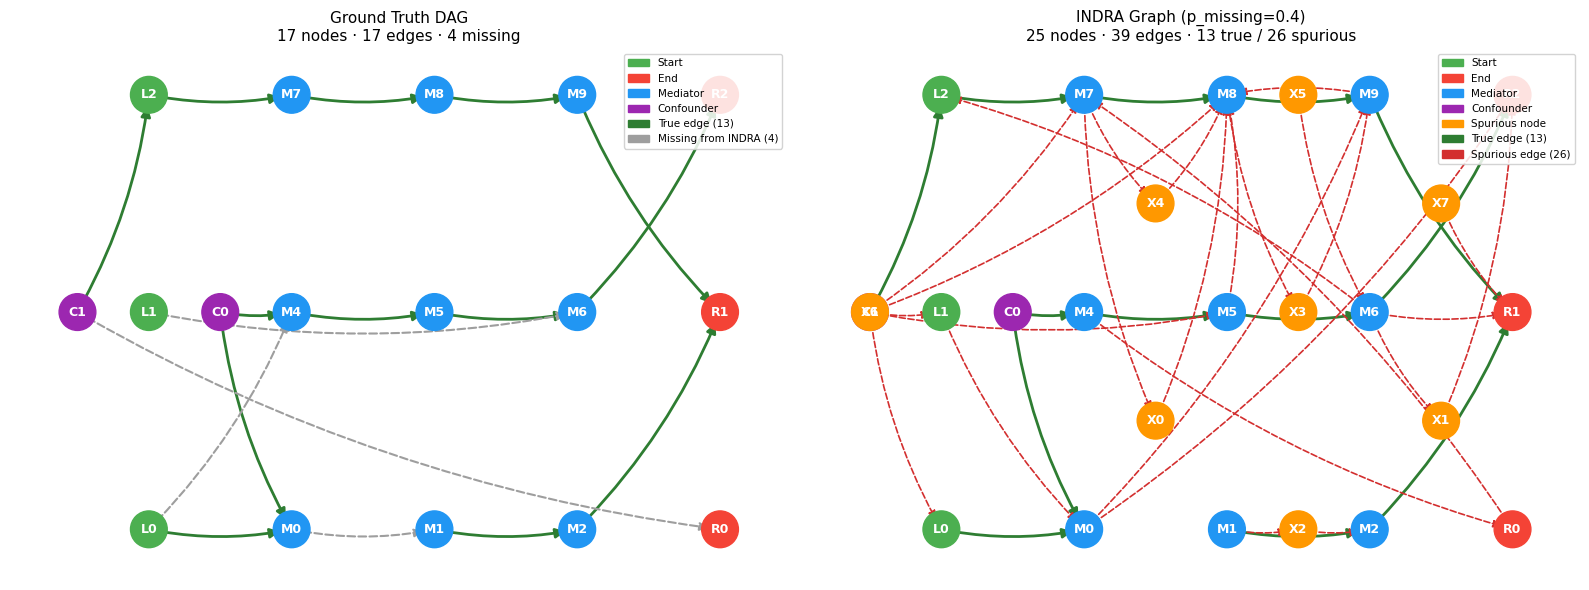

In [11]:
dag7, roles7 = generate_structured_dag(
    n_start=3, n_end=3, max_mediators=3,
    confounder_prob=0.15, shared_mediator_prob=0.4, seed=7,  # same graph as above
)
indra7, df7, missing7 = generate_indra_data(
    dag7, num_incorrect_nodes=8, num_incorrect_edges=15, p_missing_real=0.4,
)
print(f"Ground truth edges: {dag7.number_of_edges()}")
print(f"True edges in INDRA: {df7.ground_truth.sum()}  |  Spurious: {(~df7.ground_truth).sum()}")
print(f"Missing from INDRA:  {len(missing7)}")

plot_indra_comparison(dag7, roles7, indra7, missing7, p_missing_real=0.4)
plt.show()

## Example 8 — Effect of `p_missing_real` on INDRA coverage

Same ground truth graph across three missingness levels.

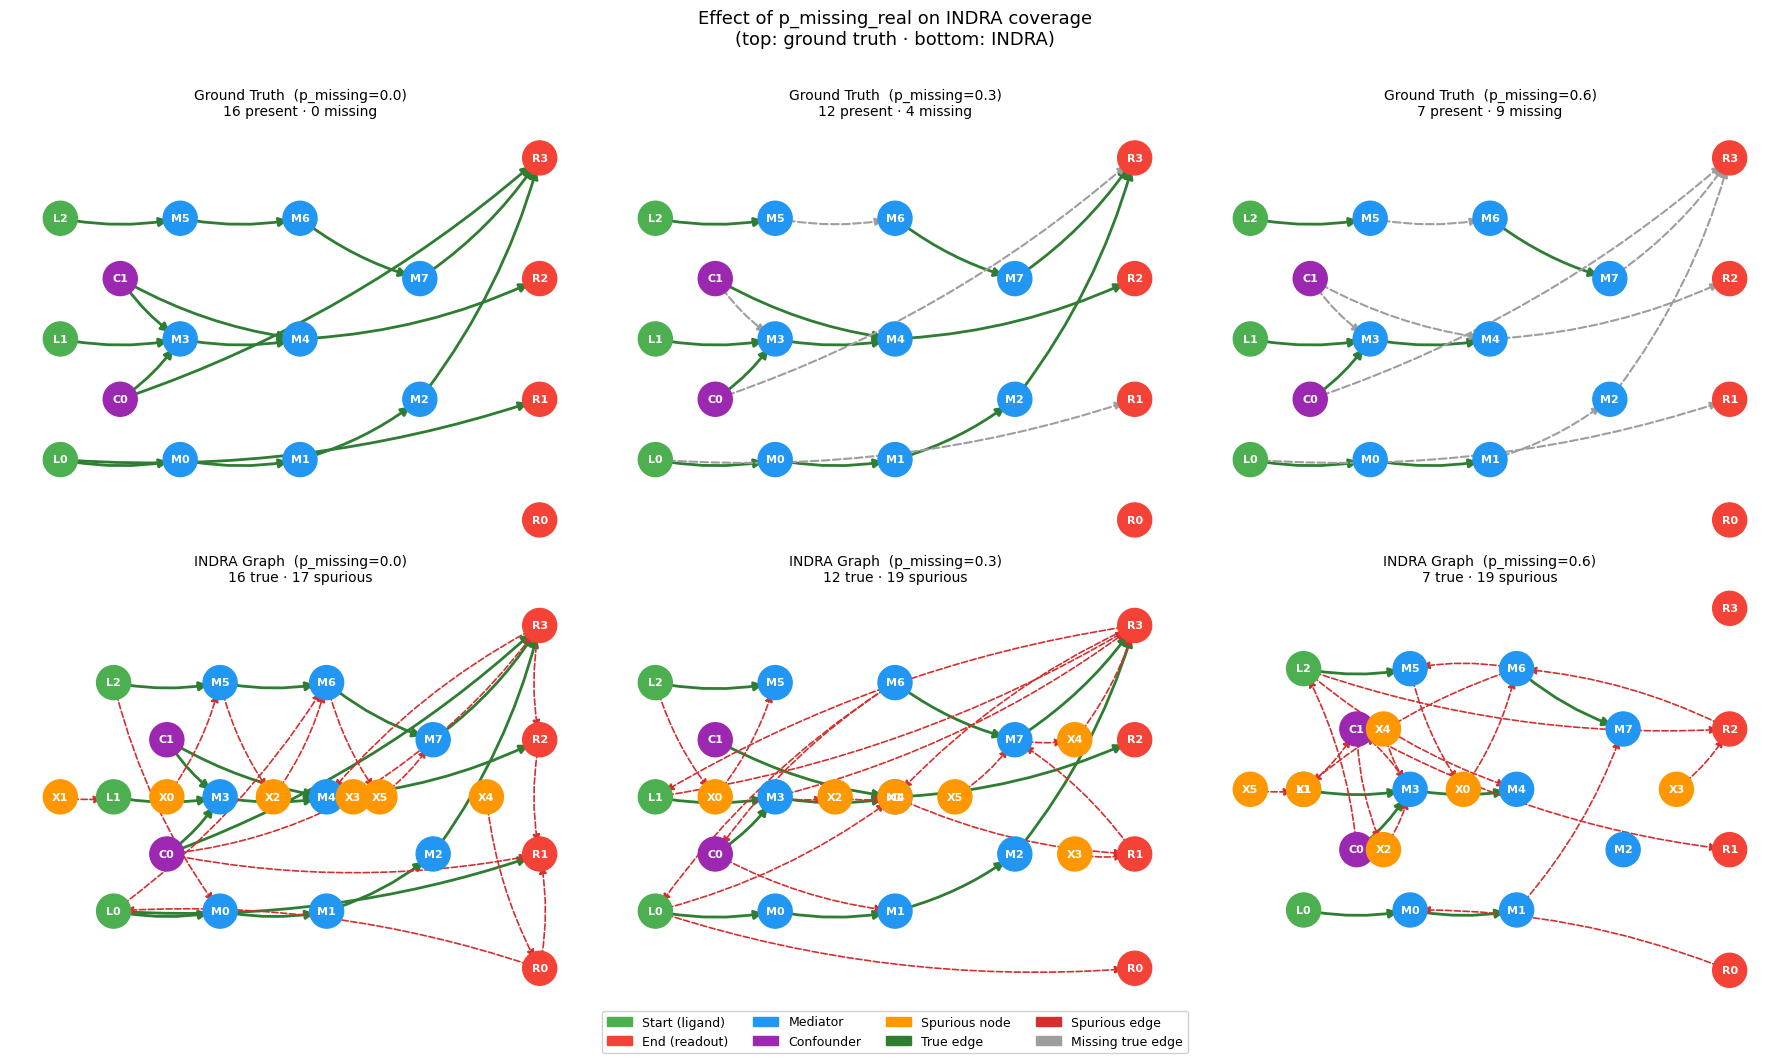

In [12]:
base_dag, base_roles = generate_structured_dag(
    n_start=3, n_end=4, max_mediators=3,
    confounder_prob=0.1, shared_mediator_prob=0.3, seed=42,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, p_miss in enumerate([0.0, 0.3, 0.6]):
    indra, df, missing = generate_indra_data(
        base_dag, num_incorrect_nodes=6, num_incorrect_edges=10, p_missing_real=p_miss,
    )
    real_nodes = set(base_dag.nodes())

    # ── Top row: ground truth with missing edges highlighted ─────────────────
    ax_gt = axes[0, col]
    gt_pos = dag_layout(base_dag, base_roles)
    present = [e for e in base_dag.edges() if e not in missing]
    absent  = list(missing)

    nx.draw_networkx_nodes(base_dag, gt_pos, ax=ax_gt,
                           node_color=node_colors(base_dag, base_roles), node_size=600)
    nx.draw_networkx_labels(base_dag, gt_pos, ax=ax_gt,
                            font_size=8, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(base_dag, gt_pos, edgelist=present, ax=ax_gt,
                           edge_color=TRUE_EDGE_COLOR, width=2.0,
                           arrows=True, arrowsize=13, connectionstyle='arc3,rad=0.1')
    if absent:
        nx.draw_networkx_edges(base_dag, gt_pos, edgelist=absent, ax=ax_gt,
                               edge_color=MISSING_EDGE_COLOR, width=1.5, style='dashed',
                               arrows=True, arrowsize=11, connectionstyle='arc3,rad=0.1')
    ax_gt.set_title(f'Ground Truth  (p_missing={p_miss})\n'
                    f'{len(present)} present · {len(absent)} missing', fontsize=10)
    ax_gt.axis('off')

    # ── Bottom row: INDRA graph ───────────────────────────────────────────────
    ax_in = axes[1, col]
    indra_pos    = indra_layout(indra, base_dag, base_roles)
    indra_colors = indra_node_colors(indra, real_nodes, base_roles)
    true_e  = [(u,v) for u,v,d in indra.edges(data=True) if d.get('ground_truth')]
    false_e = [(u,v) for u,v,d in indra.edges(data=True) if not d.get('ground_truth')]

    nx.draw_networkx_nodes(indra, indra_pos, ax=ax_in,
                           node_color=indra_colors, node_size=600)
    nx.draw_networkx_labels(indra, indra_pos, ax=ax_in,
                            font_size=8, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(indra, indra_pos, edgelist=true_e, ax=ax_in,
                           edge_color=TRUE_EDGE_COLOR, width=2.0,
                           arrows=True, arrowsize=13, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(indra, indra_pos, edgelist=false_e, ax=ax_in,
                           edge_color=FALSE_EDGE_COLOR, width=1.2, style='dashed',
                           arrows=True, arrowsize=11, connectionstyle='arc3,rad=0.1')
    ax_in.set_title(f'INDRA Graph  (p_missing={p_miss})\n'
                    f'{len(true_e)} true · {len(false_e)} spurious', fontsize=10)
    ax_in.axis('off')

# Shared legend
legend_handles = [
    mpatches.Patch(color=ROLE_COLORS['start'],       label='Start (ligand)'),
    mpatches.Patch(color=ROLE_COLORS['end'],         label='End (readout)'),
    mpatches.Patch(color=ROLE_COLORS['mediators'],   label='Mediator'),
    mpatches.Patch(color=ROLE_COLORS['confounders'], label='Confounder'),
    mpatches.Patch(color=SPURIOUS_NODE_COLOR,        label='Spurious node'),
    mpatches.Patch(color=TRUE_EDGE_COLOR,            label='True edge'),
    mpatches.Patch(color=FALSE_EDGE_COLOR,           label='Spurious edge'),
    mpatches.Patch(color=MISSING_EDGE_COLOR,         label='Missing true edge'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Effect of p_missing_real on INDRA coverage\n(top: ground truth · bottom: INDRA)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

## End-to-End Example — DAG → INDRA Evidence → Simulated Data

This section walks through the full simulation pipeline in a single example:

1. **Ground truth DAG** — structured with 5 ligands, 3 readouts, up to 3 mediators
2. **INDRA evidence** — noisy prior with many spurious nodes/edges and no missing real edges
3. **Simulated proteomics data** — generated from the real DAG; spurious INDRA nodes are  
   included as isolated (no-parent) nodes so the data matrix covers every node INDRA knows about

In [13]:
from causomic.simulation.proteomics_simulator import simulate_data

# ── 1. Ground truth DAG ───────────────────────────────────────────────────────
gt_dag, roles = generate_structured_dag(
    n_start=10,
    n_end=4,
    max_mediators=2,
    shared_mediator_prob=0.2,
    confounder_prob=0.0,
    seed=17,
)

n_real_nodes = gt_dag.number_of_nodes()
n_real_edges = gt_dag.number_of_edges()
print(f"Ground truth — {n_real_nodes} nodes, {n_real_edges} edges")
print(f"  start={roles['start']}")
print(f"  end={roles['end']}")
print(f"  mediators={roles['mediators']}")
print(f"  confounders={roles['confounders']}")

Ground truth — 27 nodes, 36 edges
  start=['L0', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9']
  end=['R0', 'R1', 'R2', 'R3']
  mediators=['M0', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12']
  confounders=[]


In [14]:
# ── 2. INDRA evidence ─────────────────────────────────────────────────────────
# num_incorrect_nodes and num_incorrect_edges are set to roughly double
# the real node/edge count so INDRA is noisier than the ground truth.
n_fake_nodes = n_real_nodes            # ~1× more nodes than real
n_fake_edges = n_real_edges        # ~5× more edges than real

indra_dag, indra_df, missing_edges = generate_indra_data(
    gt_dag,
    num_incorrect_nodes=n_fake_nodes,
    num_incorrect_edges=n_fake_edges,
    p_missing_real=0.0,
    p_on_path=0.7
)

spurious_nodes = [n for n in indra_dag.nodes() if n not in gt_dag.nodes()]

print(f"INDRA graph  — {indra_dag.number_of_nodes()} nodes, {indra_dag.number_of_edges()} edges")
print(f"  spurious nodes ({len(spurious_nodes)}): {spurious_nodes}")
print(f"  true edges in INDRA : {indra_df.ground_truth.sum()}")
print(f"  spurious edges      : {(~indra_df.ground_truth).sum()}")
print()
print("Evidence count distribution:")
print(indra_df.groupby('ground_truth')['evidence_count']
      .describe()[['count','min','50%','max']].round(1).to_string())

INDRA graph  — 54 nodes, 111 edges
  spurious nodes (27): ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26']
  true edges in INDRA : 36
  spurious edges      : 75

Evidence count distribution:
              count  min  50%   max
ground_truth                       
False          75.0  1.0  1.0   6.0
True           36.0  1.0  2.0  30.0


In [15]:
# ── 3. Simulate proteomics data ───────────────────────────────────────────────
# Build an augmented DAG = real DAG + spurious X nodes as isolated vertices.
# simulate_data uses topological sort, so isolated nodes are treated as
# independent root nodes and get their own random-normal expression values.
augmented_dag = gt_dag.copy()
for xn in spurious_nodes:
    augmented_dag.add_node(xn)   # no edges — fully isolated

print(f"Augmented DAG: {augmented_dag.number_of_nodes()} nodes "
      f"(real: {n_real_nodes}, spurious isolated: {len(spurious_nodes)})")

n_samples = 1000
sim = simulate_data(
    augmented_dag,
    n=n_samples,
    add_feature_var=False,   # protein-level only for clarity
    add_error=True,
    seed=42,
)

mid = n_samples // 2

graph_sim = dict(sim)
model_sim = dict(sim)

graph_sim["Protein_data"] = {
    node: values[:mid].copy() for node, values in sim["Protein_data"].items()
}
model_sim["Protein_data"] = {
    node: values[mid:].copy() for node, values in sim["Protein_data"].items()
}

print(f"Split simulated data into {mid} graph samples and {n_samples - mid} model samples.")

protein_data = graph_sim['Protein_data']
protein_df   = pd.DataFrame(protein_data)
print(f"\nProtein data shape: {protein_df.shape}  (samples × nodes)")
print(protein_df.describe().loc[['mean','std','min','max']].round(2).to_string())

Augmented DAG: 54 nodes (real: 27, spurious isolated: 27)
simulating data...
Split simulated data into 500 graph samples and 500 model samples.

Protein data shape: (500, 54)  (samples × nodes)
         L0     L1     L2     L3     L4     L5     L6     L7     L8     L9     X0     X1     X2     X3     X4     X5     X6     X7     X8     X9    X10    X11    X12    X13    X14    X15    X16    X17    X18    X19    X20    X21    X22    X23    X24    X25    X26     M1     M3     M4     M5     M7     M8     M9    M10    M11     M0     M6     R2     M2    M12     R0     R3     R1
mean  18.81  22.37  16.58  15.62  20.84  15.10  23.30  16.77  18.17  19.22  17.90  21.14  15.52  24.08  16.55  24.89  21.75  17.53  18.70  21.44  15.72  18.18  15.24  21.80  20.00  21.52  21.96  24.39  18.34  24.41  17.81  23.15  20.25  16.10  23.76  18.32  22.30   6.12   9.72   9.08  11.95   8.24   7.25   6.68   8.38   9.02   5.54  13.62   7.75   9.18  10.02  13.05   7.10   5.31
std    3.16   2.56   1.67   3.06   2.61 

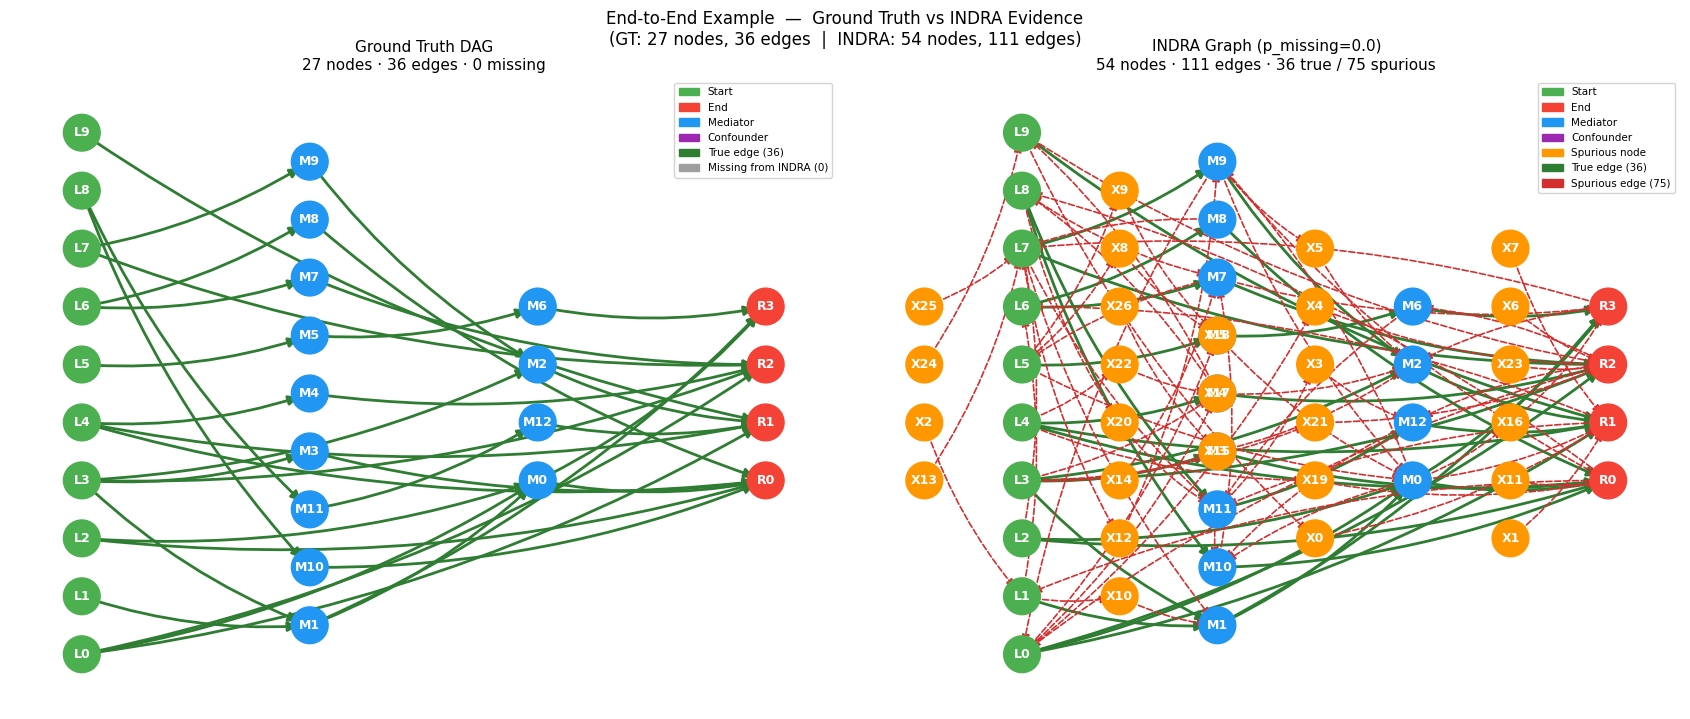

In [16]:
# ── 4. Side-by-side: ground truth vs INDRA ───────────────────────────────────
plot_indra_comparison(
    gt_dag, roles, indra_dag, missing_edges,
    p_missing_real=0.0, figsize=(17, 7),
)
plt.suptitle(
    'End-to-End Example  —  Ground Truth vs INDRA Evidence\n'
    f'(GT: {n_real_nodes} nodes, {n_real_edges} edges  |  '
    f'INDRA: {indra_dag.number_of_nodes()} nodes, {indra_dag.number_of_edges()} edges)',
    fontsize=12, y=1.02,
)
plt.show()

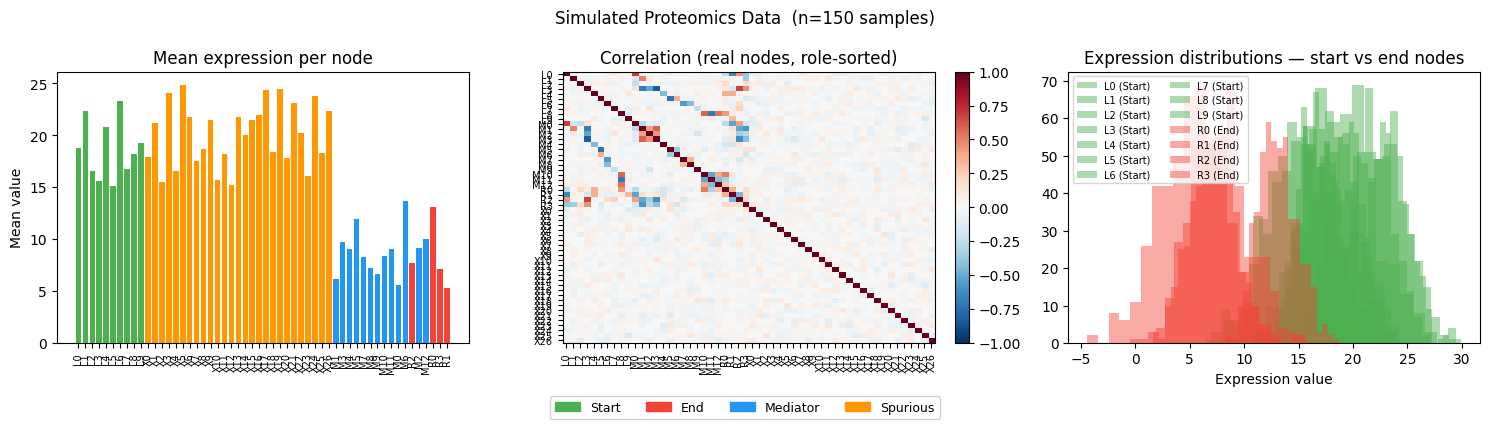

In [17]:
# ── 5. Visualise the simulated data ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

role_order = (
    [(n, 'Start')      for n in roles['start']]
    + [(n, 'Mediator') for n in roles['mediators']]
    + [(n, 'End')      for n in roles['end']]
    + [(n, 'Spurious') for n in spurious_nodes]
)
role_palette = {
    'Start':    ROLE_COLORS['start'],
    'End':      ROLE_COLORS['end'],
    'Mediator': ROLE_COLORS['mediators'],
    'Spurious': SPURIOUS_NODE_COLOR,
}

# Panel A — mean expression per node coloured by role
node_means  = protein_df.mean()
node_roles_flat = {n: r for n, r in role_order}
node_colors_bar = [role_palette[node_roles_flat.get(n, 'Mediator')] for n in node_means.index]

axes[0].bar(range(len(node_means)), node_means.values, color=node_colors_bar)
axes[0].set_xticks(range(len(node_means)))
axes[0].set_xticklabels(node_means.index, rotation=90, fontsize=7)
axes[0].set_title('Mean expression per node')
axes[0].set_ylabel('Mean value')

# Panel B — correlation heatmap (real nodes only, role-sorted)
real_order = [n for n, _ in role_order if n in protein_df.columns]
corr = protein_df[real_order].corr()
im = axes[1].imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
axes[1].set_xticks(range(len(real_order)))
axes[1].set_yticks(range(len(real_order)))
axes[1].set_xticklabels(real_order, rotation=90, fontsize=7)
axes[1].set_yticklabels(real_order, fontsize=7)
axes[1].set_title('Correlation (real nodes, role-sorted)')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# Panel C — expression distributions for start vs end nodes
for node, role in role_order:
    if role in ('Start', 'End') and node in protein_df.columns:
        axes[2].hist(protein_df[node], bins=20, alpha=0.45,
                     label=f'{node} ({role})', color=role_palette[role])
axes[2].set_title('Expression distributions — start vs end nodes')
axes[2].set_xlabel('Expression value')
axes[2].legend(fontsize=7, ncol=2)

# Role legend for panels A and B
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=r) for r, c in role_palette.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

plt.suptitle('Simulated Proteomics Data  (n=150 samples)', fontsize=12)
plt.tight_layout()
plt.show()

---

## Posterior DAG Estimation

Using the simulated data and INDRA priors from the end-to-end example, we now run
`estimate_posterior_dag` to recover the original causal graph.  The result is compared
against the ground truth using precision and recall, and visualised with edges colour-coded
as true positives, false positives, and false negatives.

In [18]:
from causomic.network import estimate_posterior_dag
from causomic.graph_construction.prior_data_reconciliation import (
    BICGaussIndraPriors,
    BICGaussNoPriors,
    AICGaussIndraPriors,
    SparseHillClimb,
)

# protein_df, indra_df, gt_dag, roles are all defined in the end-to-end cells above.
posterior, bootstraps = estimate_posterior_dag(
    protein_df,
    indra_priors=indra_df,
    prior_strength=5,
    scoring_function=AICGaussIndraPriors,#BICGaussIndraPriors,#
    search_algorithm=SparseHillClimb,
    n_bootstrap=100,
    add_high_corr_edges_to_priors=False,
    corr_threshold=0.5,
    edge_probability=0.5,
    convert_to_probability=True,
    return_bootstrap_dags=True,
    random_init=False
)
print("Posterior DAG estimated.")
print(f"  Directed edges: {len(list(posterior.directed.edges()))}")
print(f"  Undirected edges: {len(list(posterior.undirected.edges()))}")

INFO: Starting bootstrap causal discovery:
INFO: Calculating edge probabilities.
INFO: Running bootstrap.


Hill Climb Bootstraps: 100%|██████████| 100/100 [00:18<00:00,  5.45it/s]


Posterior DAG estimated.
  Directed edges: 34
  Undirected edges: 0


In [19]:
# ── Evaluate against ground truth ────────────────────────────────────────────
all_edges = set(zip(indra_df["source"], indra_df["target"]))
# Build predicted edge set from posterior directed graph
pred_edges = set(
    (str(u), str(v))
    for u, v in posterior.directed.edges()
)

# Ground truth edge set — all edges including confounders.
# Confounders are observed here (included in data and INDRA), so their
# edges are valid ground truth to recover.
observable_gt_edges = set(gt_dag.edges())

tp_edges = pred_edges & observable_gt_edges
fp_edges = pred_edges - observable_gt_edges
fn_edges = observable_gt_edges - pred_edges
tn_edges = all_edges - (tp_edges | fp_edges | fn_edges)  # true negatives (not used in precision/recall)

precision = len(tp_edges) / len(pred_edges) if pred_edges else 0.0
recall    = len(tp_edges) / len(observable_gt_edges) if observable_gt_edges else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
accuracy  = (len(tp_edges) + len(tn_edges)) / len(all_edges) if all_edges else 0.0


print(f"Ground truth edges (observable): {len(observable_gt_edges)}")
print(f"Predicted edges                : {len(pred_edges)}")
print()
print(f"  True positives  (TP): {len(tp_edges)}")
print(f"  False positives (FP): {len(fp_edges)}")
print(f"  False negatives (FN): {len(fn_edges)}")
print(f"  True negatives  (TN): {len(tn_edges)}")
print()
print(f"  Precision : {precision:.3f}")
print(f"  Recall    : {recall:.3f}")
print(f"  F1        : {f1:.3f}")
print(f"  Accuracy  : {accuracy:.3f}")

Ground truth edges (observable): 36
Predicted edges                : 34

  True positives  (TP): 29
  False positives (FP): 5
  False negatives (FN): 7
  True negatives  (TN): 70

  Precision : 0.853
  Recall    : 0.806
  F1        : 0.829
  Accuracy  : 0.892


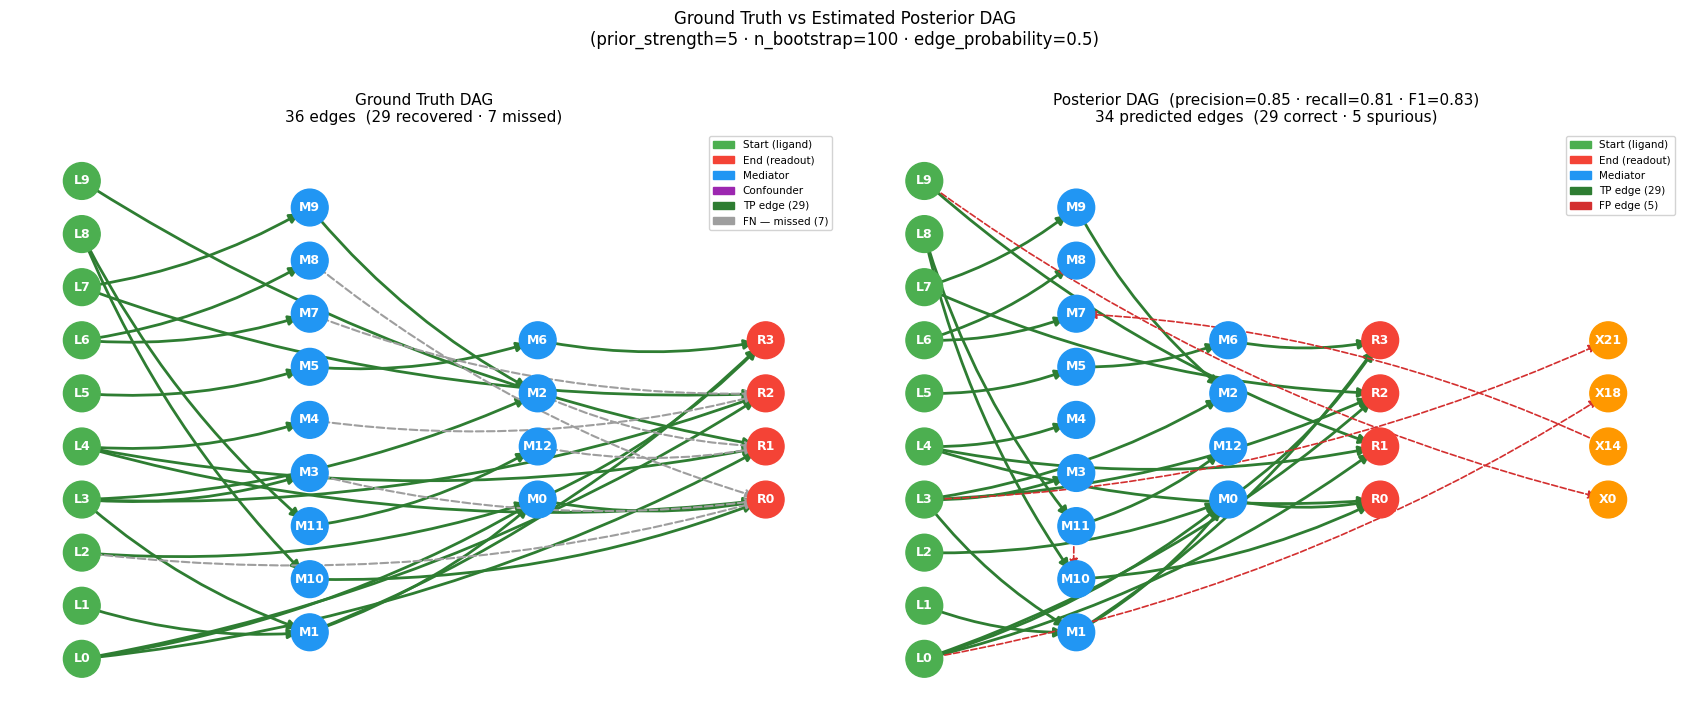

In [20]:
# ── Visualise: ground truth vs posterior ─────────────────────────────────────
TP_COLOR = '#2E7D32'   # dark green  — correctly recovered
FP_COLOR = '#D32F2F'   # dark red    — predicted but wrong
FN_COLOR = '#9E9E9E'   # grey dashed — missed by posterior

fig, (ax_gt, ax_post) = plt.subplots(1, 2, figsize=(17, 7))

# Shared node positions from the ground truth DAG
gt_pos = dag_layout(gt_dag, roles)
gt_colors = node_colors(gt_dag, roles)

# ── Left: ground truth, edges coloured by TP / FN ────────────────────────────
nx.draw_networkx_nodes(gt_dag, gt_pos, ax=ax_gt,
                       node_color=gt_colors, node_size=700)
nx.draw_networkx_labels(gt_dag, gt_pos, ax=ax_gt,
                        font_size=9, font_color='white', font_weight='bold')

tp_gt = [(u, v) for u, v in gt_dag.edges() if (u, v) in tp_edges]
fn_gt = [(u, v) for u, v in gt_dag.edges() if (u, v) in fn_edges]

nx.draw_networkx_edges(gt_dag, gt_pos, edgelist=tp_gt, ax=ax_gt,
                       edge_color=TP_COLOR, width=2.0,
                       arrows=True, arrowsize=14, connectionstyle='arc3,rad=0.1')
nx.draw_networkx_edges(gt_dag, gt_pos, edgelist=fn_gt, ax=ax_gt,
                       edge_color=FN_COLOR, width=1.5, style='dashed',
                       arrows=True, arrowsize=12, connectionstyle='arc3,rad=0.1')

gt_patches = [
    mpatches.Patch(color=c, label=l) for c, l in [
        (ROLE_COLORS['start'],       'Start (ligand)'),
        (ROLE_COLORS['end'],         'End (readout)'),
        (ROLE_COLORS['mediators'],   'Mediator'),
        (ROLE_COLORS['confounders'], 'Confounder'),
        (TP_COLOR, f'TP edge ({len(tp_gt)})'),
        (FN_COLOR, f'FN — missed ({len(fn_gt)})'),
    ]
]
ax_gt.legend(handles=gt_patches, loc='upper right', fontsize=7.5, framealpha=0.85)
ax_gt.set_title(
    f'Ground Truth DAG\n{len(observable_gt_edges)} edges  '
    f'({len(tp_gt)} recovered · {len(fn_gt)} missed)',
    fontsize=11,
)
ax_gt.axis('off')

# ── Right: posterior, edges coloured by TP / FP ──────────────────────────────
# Posterior may contain nodes not in gt_dag (spurious X nodes);
# reuse gt_pos for real nodes, place others at the right.
# posterior.directed nodes are y0 Variable objects — str() them for dict lookups
post_directed = posterior.directed
all_post_nodes = list(post_directed.nodes())
gt_str_nodes = list(gt_dag.nodes())

post_pos = {n: gt_pos[str(n)] for n in all_post_nodes if str(n) in gt_pos}
extra = [n for n in all_post_nodes if str(n) not in gt_pos]
if extra:
    x_col = max(p[0] for p in gt_pos.values()) + 3.0
    for i, n in enumerate(sorted(extra, key=str)):
        post_pos[n] = (x_col, i - len(extra) / 2.0)

post_colors = [
    gt_colors[gt_str_nodes.index(str(n))] if str(n) in gt_str_nodes
    else SPURIOUS_NODE_COLOR
    for n in all_post_nodes
]

nx.draw_networkx_nodes(post_directed, post_pos, ax=ax_post,
                       node_color=post_colors, node_size=700)
nx.draw_networkx_labels(post_directed, post_pos, ax=ax_post,
                        font_size=9, font_color='white', font_weight='bold')

tp_post = [(u, v) for u, v in post_directed.edges() if (str(u), str(v)) in tp_edges]
fp_post = [(u, v) for u, v in post_directed.edges() if (str(u), str(v)) in fp_edges]

nx.draw_networkx_edges(post_directed, post_pos, edgelist=tp_post, ax=ax_post,
                       edge_color=TP_COLOR, width=2.0,
                       arrows=True, arrowsize=14, connectionstyle='arc3,rad=0.1')
nx.draw_networkx_edges(post_directed, post_pos, edgelist=fp_post, ax=ax_post,
                       edge_color=FP_COLOR, width=1.2, style='dashed',
                       arrows=True, arrowsize=12, connectionstyle='arc3,rad=0.1')

post_patches = [
    mpatches.Patch(color=c, label=l) for c, l in [
        (ROLE_COLORS['start'],     'Start (ligand)'),
        (ROLE_COLORS['end'],       'End (readout)'),
        (ROLE_COLORS['mediators'], 'Mediator'),
        (TP_COLOR, f'TP edge ({len(tp_post)})'),
        (FP_COLOR, f'FP edge ({len(fp_post)})'),
    ]
]
ax_post.legend(handles=post_patches, loc='upper right', fontsize=7.5, framealpha=0.85)
ax_post.set_title(
    f'Posterior DAG  (precision={precision:.2f} · recall={recall:.2f} · F1={f1:.2f})\n'
    f'{len(pred_edges)} predicted edges  ({len(tp_post)} correct · {len(fp_post)} spurious)',
    fontsize=11,
)
ax_post.axis('off')

plt.suptitle(
    'Ground Truth vs Estimated Posterior DAG\n'
    '(prior_strength=5 · n_bootstrap=100 · edge_probability=0.5)',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## Train LVM

In [21]:
from causomic.causal_model.LVM import LVM
from causomic.simulation.random_network import ground_truth_interventional_effect
import pyro, torch

model_input = model_sim['Protein_data']
model_input   = pd.DataFrame(model_input)

pyro.clear_param_store()
lvm = LVM(backend="pyro", num_steps=2000, verbose=True)
lvm.fit(model_input, posterior)

Using device: cpu
Fitting LVM with pyro backend
Data shape: (500, 54)
Parsing causal graph structure...
Scaling observational data...
Found 11 root nodes and 20 descendant nodes
Processing observational data...
Setting up prior distributions...
Starting SVI training for 2000 steps with early stopping
Patience: 75, Min delta: 50
Step 0: loss=1282696.9610  ema=1282696.9610
Step 100: loss=-24343.7013  ema=-4681.2311
Step 200: loss=-46859.1256  ema=-43180.7422
Step 300: loss=-59988.0932  ema=-57813.1410
Step 400: loss=-68629.2061  ema=-67131.5748
Step 500: loss=-75325.7263  ema=-74063.2591
Step 600: loss=-80626.7621  ema=-79688.4623
Step 700: loss=-85284.1877  ema=-84453.9366
Step 800: loss=-89316.1237  ema=-88583.6382
Step 900: loss=-92805.7472  ema=-92145.4160
Step 1000: loss=-95919.1051  ema=-95312.8005
Step 1100: loss=-98622.0927  ema=-98102.2683
Step 1200: loss=-100977.4428  ema=-100528.8782
Step 1300: loss=-103034.6307  ema=-102618.6236
Step 1400: loss=-104785.9419  ema=-104436.0770


In [22]:
import torch
intervention0 = dict(zip(roles['start'], [1 for _ in roles['start']]))#{'L0': 1}
intervention1 = dict(zip(roles['start'], [0 for _ in roles['start']]))#{'L0': 0}
outcome = roles['end']

torch.manual_seed(42)
lvm.intervention(intervention0, outcome, predictive_samples=200)
int0 = lvm.intervention_samples
torch.manual_seed(42)

lvm.intervention(intervention1, outcome, predictive_samples=200)
int1 = lvm.intervention_samples

ci_results = (int0 - int1).mean(axis = 0)

In [23]:
l0_gt_int0 = ground_truth_interventional_effect(
    gt_dag,
    model_sim['Coefficients'],
    intervention_nodes = intervention0,
    output_nodes = outcome
)
l0_gt_int1 = ground_truth_interventional_effect(
    gt_dag,
    model_sim['Coefficients'],
    intervention_nodes = intervention1,
    output_nodes = outcome
)

gt_results = {k: l0_gt_int0['effect'][k] - l0_gt_int1['effect'][k] for k in l0_gt_int1['effect']}


In [24]:
ci_series = pd.Series(ci_results, index=outcome, dtype=float)
gt_series = pd.Series(gt_results, dtype=float).reindex(outcome)

differences = ci_series - gt_series

diff_df = pd.DataFrame({
    "ci_results": ci_series,
    "gt_results": gt_series,
    "difference": differences,
})

print(diff_df.round(6).to_string())

    ci_results  gt_results  difference
R0    0.405315    1.099025   -0.693710
R1    0.443345    0.569151   -0.125806
R2    1.220552    1.640540   -0.419989
R3   -0.110471   -0.114969    0.004498
